In [ ]:
!pip install librosa streamlit soundfile scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import pickle

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("SpotifyFeatures.csv")
df.head()

Saving SpotifyFeatures.csv to SpotifyFeatures (1).csv


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [ ]:
def classify_mood(row):

    if row['valence'] > 0.6 and row['energy'] > 0.6:
        return 'Happy'

    elif row['valence'] < 0.4 and row['energy'] < 0.4:
        return 'Sad'

    elif row['energy'] > 0.7:
        return 'Energetic'

    elif row['acousticness'] > 0.7:
        return 'Calm'

    else:
        return 'Neutral'

df['mood'] = df.apply(classify_mood, axis=1)

df[['track_name', 'mood']].head()

,track_name,mood
0,C'est beau de faire un Show,Happy
1,Perdu d'avance (par Gad Elmaleh),Happy
2,Don't Let Me Be Lonely Tonight,Sad
3,Dis-moi Monsieur Gordon Cooper,Sad
4,Ouverture,Sad


In [ ]:
features = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
y = df['mood']

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Encode the 'key' column which is categorical
key_encoder = LabelEncoder()
X_train['key'] = key_encoder.fit_transform(X_train['key'])
X_test['key'] = key_encoder.transform(X_test['key'])

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
pickle.dump(model, open("mood_model.pkl", "wb"))
pickle.dump(encoder, open("label_encoder.pkl", "wb"))

In [ ]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

mood = encoder.inverse_transform(prediction)

print("Predicted Mood:", mood[0])

Predicted Mood: Energetic


In [ ]:
def recommend_songs(mood):

    recommendations = df[df['mood'] == mood][
        ['track_name', 'artist_name']
    ].sample(5)

    return recommendations

recommend_songs("Happy")

,track_name,artist_name
113115,Hurts Like Hell - Feenixpawl Remix,Madison Beer
85424,Riverside,Kirk Franklin
118581,El Taxi,Pitbull
133714,Satta - Amassa - Gana,The Abyssinians
27371,I Hope You Die,Bloodhound Gang


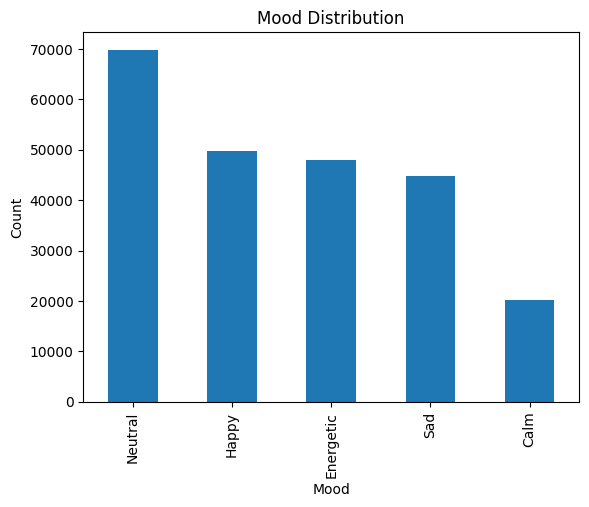

In [ ]:
df['mood'].value_counts().plot(kind='bar')

plt.title("Mood Distribution")
plt.xlabel("Mood")
plt.ylabel("Count")

plt.show()